# Advection Equation

Here we solve the advection equation $u_t + a u_x=0$ using as an initial condition a gaussian profile $u(x,t=0)=\exp{[-(x-x_0)^2]}$ with $x_0=5$.

We use a domain $x\in [0,10]$ with periodic boundary conditions and use the Leapfrog scheme.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'grid', 'high-contrast', 'no-latex'])

folder = './Leap_new/'

In [2]:
#define the speed a
a=1.0

# Define the domain
L = 10.0     # Domain length
nx = 101    # Number of grid points
dx = L/(nx-1)   # Grid spacing
x = np.linspace(0, L, nx)

##print(x,'\n',dx) #just a check

# Define the time step and the final time
cf = 0.5
dt = cf*dx/a   # Time step
t_final = 20.0

print('nx=',nx)
print('dx=',dx)
print('dt=',dt)
print('Number of iterations=',t_final/dt)


# Define the initial condition
x0=5
u_initial = np.exp(-(x-x0)**2)

# Initialize the solution array
u_current = u_initial.copy()

#we create arrays where we will store the time and the l2norm
l2norm=[]
l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))

time=[]
time.append(0.0)

nx= 101
dx= 0.1
dt= 0.05
Number of iterations= 400.0


In [4]:
import os
##create directory where to save images
print(os.getcwd())

#os.makedirs(folder)

os.listdir('./')

C:\Users\lm101\Desktop\Uni\numerical_relativity_2025\Advection


['.ipynb_checkpoints',
 'Advection_Equation.ipynb',
 'Advection_Equation_Leapfrog.ipynb',
 'Advection_Equation_LF.ipynb',
 'Advection_Equation_LW.ipynb',
 'AE_Step_LF.ipynb',
 'AE_Step_LW.ipynb',
 'FTCS',
 'images',
 'images_Leapfrog',
 'images_LF',
 'images_LW',
 'img_SF_LF',
 'img_SF_LW',
 'l2norm_FTCS.dat',
 'l2norm_LAX.dat',
 'l2norm_LAXWENDROFF.dat',
 'l2norm_LEAPFROG.dat',
 'Lax_fried',
 'Leap_new',
 'movie_Leapfrog.mp4',
 'movie_LW.mp4',
 'movie_SF_LF.mp4',
 'movie_SF_LW.mp4',
 'README.md']

In [5]:
# Initilize time and iteration counter
t = 0.0
i = 0
j = 0

l2_check = []
l2_check.append(np.sqrt(np.sum(u_current**2)/len(u_current)))

t_check = 0.5
t_i = [0.0]

#save the initial conditions
plt.plot(x, u_current)
plt.title('Time='+str(round(t,2)))
plt.ylim(-0.2,1.1)
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.savefig(folder + 'fig_'+str(i).zfill(5)+'.png', dpi=200)
plt.close()


#solve the advection equation
while t < t_final:
    # Compute the new solution using the Leapfrog method
    # Note: np.roll(u_current, -1) is equivalent to u(j+1) and
    #       np.roll(u_current,  1) is equivalent to u(j-1)
    # using np.roll is equivalent to use periodic boundary conditions

    #we fix the initial condition by using the analytical solution
    if i == 0:  u_next = np.exp(-(x- (a * dt)-x0)**2)
    else: u_next = u_prior - a*dt/(dx)*(np.roll(u_current, -1) - np.roll(u_current, 1))    
    
    # Update the solution
    #u_prior corresponds to u(n-1, j) in the next run
    u_prior = u_current.copy() 
    u_current = u_next.copy()
    
    
    #advance the time 
    t += dt
    i += 1
    
    #compute the l2 norm and add the time to the time vector
    l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))
    time.append(t)

    if(t >= t_check): 
        l2_check.append(np.sqrt(np.sum(u_current**2)/len(u_current)))
        t_check += 0.5
        t_i.append(t_check)
        
    #plot the current result and save in an image every 10 iterations
    if (i%10==0 or t>=t_final):
        plt.plot(x, u_current)
        plt.title('Time='+str(round(t,2)))
        plt.xlabel('$x$')
        plt.ylabel('$u(x)$')
        plt.ylim(-0.2,1.1)
        plt.savefig(folder + 'fig_'+str(i).zfill(5)+'.png', dpi=200)
        plt.close()


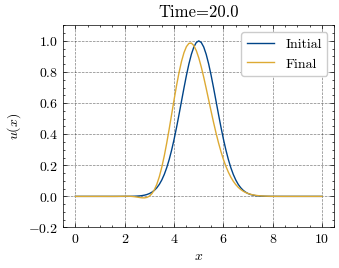

In [6]:
# Plot the final solution
plt.plot(x, u_initial, label='Initial')
plt.plot(x, u_current, label='Final')
plt.title('Time=20.0')
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.ylim(-0.2,1.1)
plt.legend()
plt.savefig(folder + 'fig_final.png', dpi=200)
plt.show()

In [11]:
# set the directory where your images are stored
directory = "./images_Leapfrog/"

# get the list of image files in the directory
files = os.listdir(directory)

print(files, '\n')

# sort the files in alphanumeric order
files=sorted(files)

print(files)

['fig_00000.png', 'fig_00010.png', 'fig_00020.png', 'fig_00030.png', 'fig_00040.png', 'fig_00050.png', 'fig_00060.png', 'fig_00070.png', 'fig_00080.png', 'fig_00090.png', 'fig_00100.png', 'fig_00110.png', 'fig_00120.png', 'fig_00130.png', 'fig_00140.png', 'fig_00150.png', 'fig_00160.png', 'fig_00170.png', 'fig_00180.png', 'fig_00190.png', 'fig_00200.png', 'fig_00210.png', 'fig_00220.png', 'fig_00230.png', 'fig_00240.png', 'fig_00250.png', 'fig_00260.png', 'fig_00270.png', 'fig_00280.png', 'fig_00290.png', 'fig_00300.png', 'fig_00310.png', 'fig_00320.png', 'fig_00330.png', 'fig_00340.png', 'fig_00350.png', 'fig_00360.png', 'fig_00370.png', 'fig_00380.png', 'fig_00390.png', 'fig_00400.png'] 

['fig_00000.png', 'fig_00010.png', 'fig_00020.png', 'fig_00030.png', 'fig_00040.png', 'fig_00050.png', 'fig_00060.png', 'fig_00070.png', 'fig_00080.png', 'fig_00090.png', 'fig_00100.png', 'fig_00110.png', 'fig_00120.png', 'fig_00130.png', 'fig_00140.png', 'fig_00150.png', 'fig_00160.png', 'fig_00170

In [12]:
from moviepy import ImageSequenceClip

clip = ImageSequenceClip('./images_Leapfrog/', fps = 7)
clip.write_videofile('movie_Leapfrog.mp4')
clip.close()

MoviePy - Building video movie_Leapfrog.mp4.
MoviePy - Writing video movie_Leapfrog.mp4



MoviePy - Done !
MoviePy - video ready movie_Leapfrog.mp4


In [13]:
# don't worry about the code in this cell, it is just to let you 
# display the movies you generated above in Jupyter notebook
from IPython.display import HTML

HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="./movie_Leapfrog.mp4" type="video/mp4">
</video></div>""")

We plot the L2 norm, normalising it with the initial value.

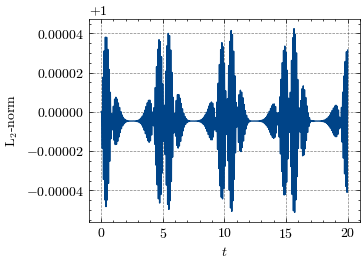

In [10]:
plt.plot(time,l2norm/l2norm[0])
plt.xlabel('$t$')
plt.ylabel('L$_2$-norm')
plt.savefig(folder+'/l2norm.png', dpi=200)
plt.show()

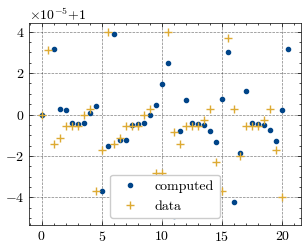

In [9]:
#Compare with data stored
l2_saved=np.genfromtxt('./l2norm_LEAPFROG.dat', comments='#')
plt.plot(t_i,l2_check/l2_check[0], '.', label = 'computed')
plt.plot(l2_saved[:,0], l2_saved[:,1]/l2_saved[0,1], '+', label = 'data')
plt.legend()
plt.show()